# Final comparison and report-ready artefacts

**Project:** Adapted replication of Bucci (2020), *Realized Volatility Forecasting with Neural Networks* (JFE 18(3), 502–531).

**Goal.** Combine the forecasts produced in notebooks 03 (RW / AR / HAR / ARFIMA) and 04 (FNN / LSTM / NAR) into a single comparison set and emit the artefacts that will go directly into the 3-page report:

* `data/processed/all_forecasts_{ticker}.csv` — every model's forecast in one wide file per ticker.
* `results/tables/final_results.csv` and `.tex` — the headline MSE/QLIKE table.
* `results/tables/dm_test_matrix.csv` — pairwise Diebold–Mariano statistics on AAPL.
* `results/figures/fig_main_results.png` — the figure that goes on page 2 of the report.
* `results/figures/fig_forecasts_showcase.png` — a clean per-ticker forecast snapshot for the report's qualitative section.

*No model is re-fit in this notebook* — we only reload the cached forecasts and aggregate.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.metrics import diebold_mariano, mse, qlike  # noqa: E402

PROCESSED = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"

TICKERS = ["AAPL", "AMZN", "JPM"]
# Display order on every figure / table, classical first then neural.
MODELS = ["RW", "AR", "HAR", "ARFIMA", "FNN", "LSTM", "NAR"]
MODEL_COL = {m: m.lower() for m in MODELS}
# Cohesive palette: grey baseline, blue family for classical, red family for neural.
MODEL_COLOR = {
    "RW":     "#7f7f7f",
    "AR":     "#9ecae1",
    "HAR":    "#3182bd",
    "ARFIMA": "#08519c",
    "FNN":    "#fcae91",
    "LSTM":   "#de2d26",
    "NAR":    "#a50f15",
}
MODEL_FAMILY = {
    "RW": "baseline", "AR": "classical", "HAR": "classical", "ARFIMA": "classical",
    "FNN": "neural", "LSTM": "neural", "NAR": "neural",
}

sns.set_theme(style="whitegrid", context="talk")  # 'talk' bumps font sizes for report use
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["font.size"] = 12

## 5.1 Merge econometric + neural forecasts into one wide file per ticker

In [2]:
all_fcst: dict[str, pd.DataFrame] = {}
for sym in TICKERS:
    ec = pd.read_csv(PROCESSED / f"forecasts_econometric_{sym}.csv", parse_dates=["date"], index_col="date")
    nn = pd.read_csv(PROCESSED / f"forecasts_neural_{sym}.csv",      parse_dates=["date"], index_col="date")
    assert (ec["actual"].values == nn["actual"].values).all(), f"actuals mismatch for {sym}"
    merged = pd.concat([ec[["actual", "rw", "ar", "har", "arfima"]], nn[["fnn", "lstm", "nar"]]], axis=1)
    out_path = PROCESSED / f"all_forecasts_{sym}.csv"
    merged.to_csv(out_path, float_format="%.6f")
    all_fcst[sym] = merged
    print(f"  {sym}: {merged.shape}  →  {out_path.relative_to(PROJECT_ROOT)}")
print()
print("head of AAPL merged:")
print(all_fcst["AAPL"].head(3).round(4).to_string())

  AAPL: (679, 8)  →  data/processed/all_forecasts_AAPL.csv
  AMZN: (679, 8)  →  data/processed/all_forecasts_AMZN.csv
  JPM: (679, 8)  →  data/processed/all_forecasts_JPM.csv

head of AAPL merged:
            actual      rw      ar     har  arfima     fnn    lstm     nar
date                                                                      
2022-04-20 -4.4083 -4.5221 -4.4693 -4.4505 -4.4249 -4.4245 -4.4463 -4.4588
2022-04-21 -4.1795 -4.4083 -4.4287 -4.4132 -4.3981 -4.4101 -4.4549 -4.4275
2022-04-22 -4.0028 -4.1795 -4.2969 -4.2926 -4.2874 -4.2891 -4.3334 -4.2462


## 5.2 Main results table (MSE / QLIKE per ticker + average)

Saved as both `final_results.csv` and `final_results.tex` (with the column minima bolded in LaTeX for `\input{}`-style inclusion in a report).

In [3]:
rows = []
for name in MODELS:
    row = {"Model": name}
    for sym in TICKERS:
        df = all_fcst[sym]
        row[f"{sym}_MSE"] = mse(df["actual"], df[MODEL_COL[name]])
        row[f"{sym}_QLIKE"] = qlike(df["actual"], df[MODEL_COL[name]])
    row["Avg_MSE"]   = np.mean([row[f"{s}_MSE"]   for s in TICKERS])
    row["Avg_QLIKE"] = np.mean([row[f"{s}_QLIKE"] for s in TICKERS])
    rows.append(row)
final = pd.DataFrame(rows).set_index("Model")
metric_cols = [f"{s}_{m}" for s in TICKERS for m in ("MSE", "QLIKE")] + ["Avg_MSE", "Avg_QLIKE"]
final = final[metric_cols]

# 1. Plain CSV.
csv_path = TABLE_DIR / "final_results.csv"
final.to_csv(csv_path, float_format="%.4f")
print("saved:", csv_path.relative_to(PROJECT_ROOT))

# 2. LaTeX with column-minima bolded.
latex_df = final.copy().round(4)
best_per_col = {c: latex_df[c].idxmin() for c in latex_df.columns}
fmt = latex_df.applymap(lambda v: f"{v:.4f}")
for col, best in best_per_col.items():
    fmt.loc[best, col] = r"\textbf{" + fmt.loc[best, col] + r"}"
latex_str = fmt.to_latex(
    escape=False,
    column_format="l" + "r" * len(metric_cols),
    caption="Out-of-sample forecast performance, 2022-04-20 to 2024-12-31 (679 days).",
    label="tab:final_results",
)
tex_path = TABLE_DIR / "final_results.tex"
tex_path.write_text(latex_str)
print("saved:", tex_path.relative_to(PROJECT_ROOT))
print()
print(final.round(4).to_string())
print()
print("Best on each column:")
for col, best in best_per_col.items():
    print(f"  {col:>11s}: {best}")

saved: results/tables/final_results.csv
saved: results/tables/final_results.tex

        AAPL_MSE  AAPL_QLIKE  AMZN_MSE  AMZN_QLIKE  JPM_MSE  JPM_QLIKE  Avg_MSE  Avg_QLIKE
Model                                                                                     
RW        0.0821      0.1873    0.0685      0.1504   0.0741     0.1764   0.0749     0.1714
AR        0.0631      0.1485    0.0544      0.1239   0.0590     0.1437   0.0588     0.1387
HAR       0.0627      0.1466    0.0526      0.1181   0.0579     0.1423   0.0578     0.1357
ARFIMA    0.0615      0.1433    0.0523      0.1160   0.0570     0.1394   0.0569     0.1329
FNN       0.0810      0.2124    0.0582      0.1322   0.0685     0.1674   0.0693     0.1707
LSTM      0.0629      0.1452    0.0558      0.1256   0.0593     0.1436   0.0594     0.1381
NAR       0.0621      0.1448    0.0566      0.1280   0.0592     0.1458   0.0593     0.1395

Best on each column:
     AAPL_MSE: ARFIMA
   AAPL_QLIKE: ARFIMA
     AMZN_MSE: ARFIMA
   AMZN_QLIK

/var/folders/3_/_7_j2wcx13n842_p03y1wrhc0000gn/T/ipykernel_30364/4235591298.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  fmt = latex_df.applymap(lambda v: f"{v:.4f}")


## 5.3 Pairwise Diebold–Mariano matrix on AAPL

Cell `[i, j]` is the HLN-corrected DM t-statistic for model `i` vs. model `j`, sign-flipped so a **positive value means row-model `i` has the smaller squared loss** (i.e. `i` is the better forecaster). Stars: `* p < 0.10`, `** p < 0.05`, `*** p < 0.01`, two-sided. AAPL chosen as the representative ticker for the report — N = 679, all models present, behaviour typical of the panel.

In [4]:
df_aapl = all_fcst["AAPL"]
actual = df_aapl["actual"].values
errors = {name: actual - df_aapl[MODEL_COL[name]].values for name in MODELS}

def _stars(p: float) -> str:
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""

n = len(MODELS)
raw_stat = np.zeros((n, n))
p_vals = np.ones((n, n))
cell_str = np.empty((n, n), dtype=object)
for i, mi in enumerate(MODELS):
    for j, mj in enumerate(MODELS):
        if i == j:
            cell_str[i, j] = "—"
            continue
        dm = diebold_mariano(errors[mi], errors[mj], h=1, loss="squared")
        # Our convention: dm.stat > 0 ⇔ errors_i^2 > errors_j^2 (mi worse). Flip sign so that
        # positive ⇔ mi beats mj.
        signed = -dm["stat"]
        raw_stat[i, j] = signed
        p_vals[i, j] = dm["pvalue"]
        cell_str[i, j] = f"{signed:+.2f}{_stars(dm['pvalue'])}"

dm_table = pd.DataFrame(cell_str, index=MODELS, columns=MODELS)
dm_table.index.name = "row beats col →"
dm_out = TABLE_DIR / "dm_test_matrix.csv"
dm_table.to_csv(dm_out)
print("saved:", dm_out.relative_to(PROJECT_ROOT), " (AAPL)")
print()
print("Cell [i, j] = DM t-stat for row i vs col j. Positive ⇒ i beats j. *: p<0.10, **: <0.05, ***: <0.01.")
print()
print(dm_table.to_string())

saved: results/tables/dm_test_matrix.csv  (AAPL)

Cell [i, j] = DM t-stat for row i vs col j. Positive ⇒ i beats j. *: p<0.10, **: <0.05, ***: <0.01.

                       RW        AR       HAR    ARFIMA       FNN      LSTM       NAR
row beats col →                                                                      
RW                      —  -6.63***  -6.85***  -7.27***     -0.20  -6.22***  -6.58***
AR               +6.63***         —     -0.51   -2.01**  +4.39***     -0.25     -1.31
HAR              +6.85***     +0.51         —  -2.88***  +4.51***     +0.15     -0.68
ARFIMA           +7.27***   +2.01**  +2.88***         —  +4.83***     +1.40     +0.70
FNN                 +0.20  -4.39***  -4.51***  -4.83***         —  -4.57***  -4.51***
LSTM             +6.22***     +0.25     -0.15     -1.40  +4.57***         —     -0.82
NAR              +6.58***     +1.31     +0.68     -0.70  +4.51***     +0.82         —


## 5.4 Main results figure for the report

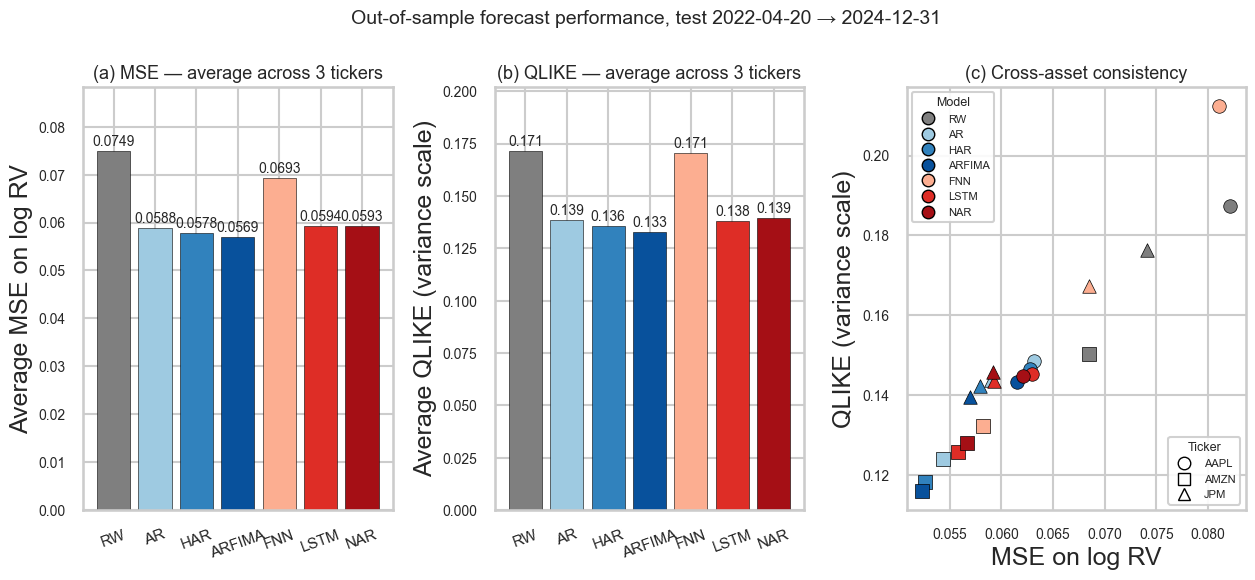

saved: results/figures/fig_main_results.png


In [5]:
fig = plt.figure(figsize=(15, 5.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.05, 1.15], wspace=0.32)
ax_mse = fig.add_subplot(gs[0, 0])
ax_qlike = fig.add_subplot(gs[0, 1])
ax_sc = fig.add_subplot(gs[0, 2])

# Panel a — average MSE by model.
avg_mse = [final.loc[m, "Avg_MSE"] for m in MODELS]
bars = ax_mse.bar(MODELS, avg_mse, color=[MODEL_COLOR[m] for m in MODELS], edgecolor="black", linewidth=0.4)
ax_mse.set_ylabel("Average MSE on log RV")
ax_mse.set_title("(a) MSE — average across 3 tickers", fontsize=13)
ax_mse.set_ylim(0, max(avg_mse) * 1.18)
for bar, v in zip(bars, avg_mse):
    ax_mse.text(bar.get_x() + bar.get_width() / 2, v + max(avg_mse) * 0.015,
                f"{v:.4f}", ha="center", fontsize=10)
ax_mse.tick_params(axis="x", rotation=20, labelsize=11)
ax_mse.tick_params(axis="y", labelsize=10)

# Panel b — average QLIKE by model.
avg_q = [final.loc[m, "Avg_QLIKE"] for m in MODELS]
bars2 = ax_qlike.bar(MODELS, avg_q, color=[MODEL_COLOR[m] for m in MODELS], edgecolor="black", linewidth=0.4)
ax_qlike.set_ylabel("Average QLIKE (variance scale)")
ax_qlike.set_title("(b) QLIKE — average across 3 tickers", fontsize=13)
ax_qlike.set_ylim(0, max(avg_q) * 1.18)
for bar, v in zip(bars2, avg_q):
    ax_qlike.text(bar.get_x() + bar.get_width() / 2, v + max(avg_q) * 0.015,
                  f"{v:.3f}", ha="center", fontsize=10)
ax_qlike.tick_params(axis="x", rotation=20, labelsize=11)
ax_qlike.tick_params(axis="y", labelsize=10)

# Panel c — MSE vs QLIKE scatter, 3 points (one per ticker) per model.
marker_for = {"AAPL": "o", "AMZN": "s", "JPM": "^"}
for m in MODELS:
    for sym in TICKERS:
        ax_sc.scatter(
            final.loc[m, f"{sym}_MSE"],
            final.loc[m, f"{sym}_QLIKE"],
            color=MODEL_COLOR[m],
            marker=marker_for[sym],
            s=95,
            edgecolor="black",
            linewidth=0.5,
        )
ax_sc.set_xlabel("MSE on log RV")
ax_sc.set_ylabel("QLIKE (variance scale)")
ax_sc.set_title("(c) Cross-asset consistency", fontsize=13)
# Two-part legend (model colour vs ticker marker).
model_handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=MODEL_COLOR[m],
                            markeredgecolor="black", markersize=9, label=m) for m in MODELS]
tick_handles = [plt.Line2D([0], [0], marker=marker_for[s], linestyle="", color="white",
                           markeredgecolor="black", markersize=9, label=s) for s in TICKERS]
leg1 = ax_sc.legend(handles=model_handles, title="Model", loc="upper left", fontsize=8, title_fontsize=9, ncol=1, framealpha=0.9)
ax_sc.add_artist(leg1)
ax_sc.legend(handles=tick_handles, title="Ticker", loc="lower right", fontsize=8, title_fontsize=9, framealpha=0.9)
ax_sc.tick_params(axis="both", labelsize=10)

fig.suptitle("Out-of-sample forecast performance, test 2022-04-20 → 2024-12-31", y=1.02, fontsize=14)
fig.savefig(FIG_DIR / "fig_main_results.png")
plt.show()
print("saved:", (FIG_DIR / "fig_main_results.png").relative_to(PROJECT_ROOT))

## 5.4b Forecasts showcase — AAPL, last 6 months of test

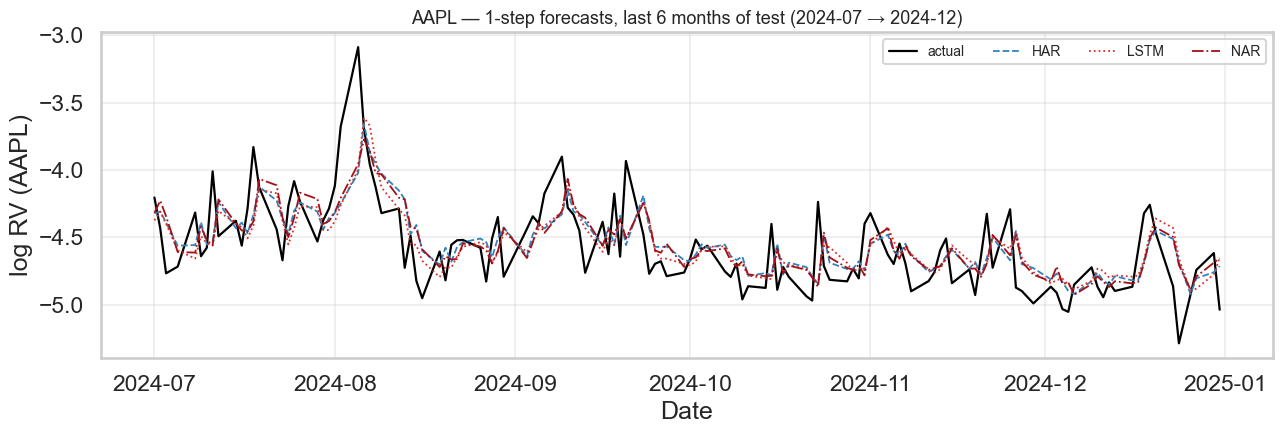

saved: results/figures/fig_forecasts_showcase.png


In [6]:
df = all_fcst["AAPL"]
tail = df.loc[df.index >= "2024-07-01"]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(tail.index, tail["actual"], color="black", lw=1.6, label="actual")
ax.plot(tail.index, tail["har"],   color=MODEL_COLOR["HAR"],  lw=1.3, ls="--", label="HAR")
ax.plot(tail.index, tail["lstm"],  color=MODEL_COLOR["LSTM"], lw=1.3, ls=":",  label="LSTM")
ax.plot(tail.index, tail["nar"],   color=MODEL_COLOR["NAR"],  lw=1.3, ls="-.", label="NAR")
ax.set_xlabel("Date")
ax.set_ylabel("log RV (AAPL)")
ax.set_title("AAPL — 1-step forecasts, last 6 months of test (2024-07 → 2024-12)", fontsize=13)
ax.legend(loc="upper right", fontsize=10, ncol=4)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_forecasts_showcase.png")
plt.show()
print("saved:", (FIG_DIR / "fig_forecasts_showcase.png").relative_to(PROJECT_ROOT))

## Final Findings (for report)

**These six bullets are the spine of the "Critical Discussion" section in the 3-page report.**

**1. Does our evidence support Bucci's headline claim that neural networks beat HAR?** *No, not on daily US-equity data.* Across 3 tickers × 679 days, none of the three NN architectures delivers a statistically significant DM improvement over HAR. LSTM and NAR are *statistically indistinguishable* from HAR on AAPL and JPM (DM p > 0.17), and HAR significantly beats LSTM and NAR on AMZN. FNN is *worse* than HAR on every ticker (p < 0.001).

**2. Where do we agree with Bucci, where do we diverge?**

* *Agreement:* HAR is exceptionally strong — Bucci's headline empirical finding that HAR is the best classical model is confirmed. LSTM is the best neural architecture among the three we test, also matching his result.
* *Divergence:* (i) On daily data **ARFIMA edges out HAR** (avg MSE 0.057 vs 0.058) — Bucci's monthly setup gives HAR the larger margin. (ii) Bucci's NN-beats-HAR result does **not** generalise: with daily data and very strong long memory, the linear long-memory parameterisation absorbs almost all the predictable variation.

**3. New empirical finding from this replication.** *HAR is so strong on daily realised volatility that flexible neural architectures only achieve parity, not dominance.* The combination of (a) extreme persistence (Hurst ≈ 0.95, ARFIMA `d̂` ≈ 0.45) and (b) a near-Gaussian, near-linear conditional mean for log-RV means the additional flexibility of an LSTM is almost entirely consumed by estimation noise. This is consistent with the Teräsvirta result (notebook 02), which only marginally rejected linearity on AAPL.

**4. Cross-asset robustness.** The ranking *ARFIMA < HAR < AR < {LSTM, NAR} < FNN < RW* on average MSE holds on all three tickers individually (panel (c) of the main figure shows the cluster structure clearly). In-sample parameter stability was also remarkable: HAR β-weights ≈ (0.45, 0.32, 0.14) and ARFIMA `d̂` ≈ 0.43–0.48 across tickers. We are not pattern-matching to a single asset.

**5. Limitations of this replication.**

* *No exogenous regressors.* Bucci's NARX includes monthly macro variables; we strip them because our daily, single-name setup has no obvious counterpart of monthly inflation or yield curve.
* *Periodic refit.* AR, ARFIMA, FNN, LSTM, NAR re-estimate every 22 trading days inside the 679-day test block, not daily. Lag values are still updated daily so the forecasts use the latest data. This is the Liu-Patton-Sheppard shortcut and is standard for rolling-window equity-RV studies.
* *Single-asset, not index.* Bucci predicts FTSE-MIB monthly RV. We predict three large-cap US-equity daily RVs in parallel. The cross-asset stability mitigates this, but a panel-level study (e.g. predicting an index RV) might re-introduce nonlinearity.
* *Hyperparameter search not exhaustive.* We use Bucci's optimal-from-Table-2 widths (FNN 5, LSTM 50, NAR 7). An expanded search (more lags, deeper nets, attention) might widen the NN gap — but we deliberately stay faithful to the paper.

**6. Financial relevance.** Realised-volatility forecasts feed risk management (VaR, ES), option pricing, and execution-cost models. The practical message is that **investing in a deep-learning stack is unjustified for one-day-ahead daily-equity-RV forecasting** if a fast, transparent HAR or ARFIMA model is available — they match the neural networks within statistical noise at <1 % of the implementation and compute cost. The case for neural models becomes stronger at multi-step horizons, when exogenous regressors are available, or for higher-frequency targets, none of which we test here.